In [1]:
from pathlib import Path
import librosa
import matplotlib.pyplot as plt
import numpy as np
from test_vectorized import read_audio_chunk
from stft import short_time_calc, plot_spectrogram

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")

In [2]:
audio_file = DATA_22 / "20230422_171301.wav"

In [3]:
f_s, audio_array = read_audio_chunk(audio_file, 0, duration_hour=0.001)

In [4]:
f_seg, t_seg, Zxx_seg, fs_new = short_time_calc(audio_array, f_s, 1000)

In [5]:
n_fft = int(f_s * 0.128)      # 128 samples, same as your STFT
hop = int(n_fft * 0.25)       # 32 samples, same as your STFT (75% overlap)

mfcc = librosa.feature.mfcc(
    y=audio_array.astype(np.float32), sr=f_s,
    n_mfcc=14, n_mels=20,
    n_fft=n_fft, hop_length=hop, window="hamming",
)
mfcc = mfcc[1:] 

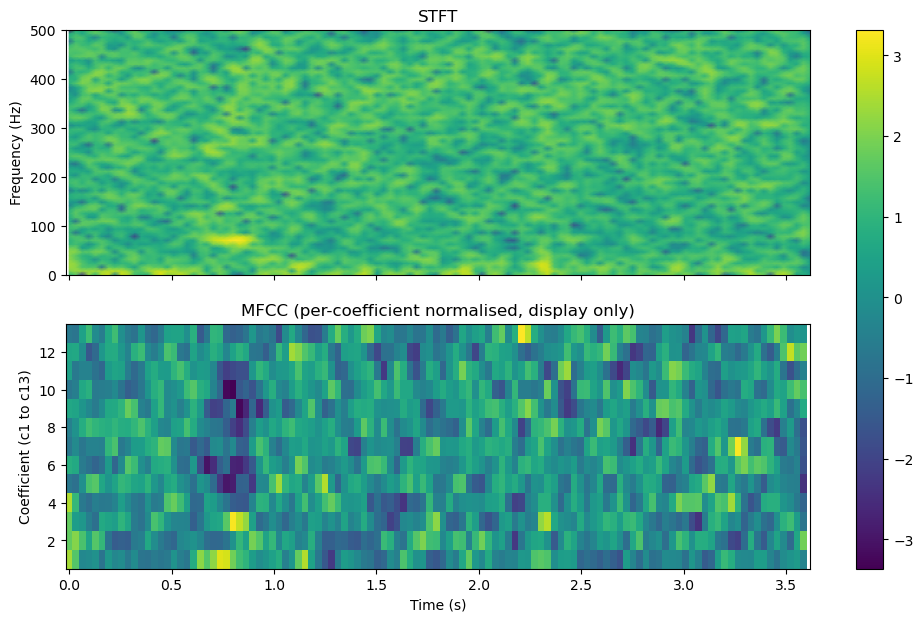

In [6]:
def plot_features(feat, fs, hop, ax, title, ylabel, normalise=True):
    """Plot any (n_rows, n_frames) feature matrix against real time."""
    img_data = feat
    if normalise:  # display only: stops one large row from washing out the rest
        img_data = (feat - feat.mean(axis=1, keepdims=True)) / (feat.std(axis=1, keepdims=True) + 1e-9)
    t = np.arange(feat.shape[1]) * hop / fs
    img = ax.pcolormesh(t, np.arange(1, feat.shape[0] + 1), img_data, shading="nearest", cmap="viridis")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    return img


f, t, Zxx, _ = short_time_calc(audio_array, f_s, fs_new)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].pcolormesh(t, f, np.log(np.abs(Zxx) + 1e-16), shading="gouraud")
axes[0].set_title("STFT")
axes[0].set_ylabel("Frequency (Hz)")

img = plot_features(mfcc, f_s, hop, axes[1], "MFCC (per-coefficient normalised, display only)", "Coefficient (c1 to c13)")
axes[1].set_xlabel("Time (s)")
fig.colorbar(img, ax=axes)
plt.show()